In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [183]:
df = pd.read_csv(r'Mental Health Dataset.csv')

In [184]:
df.shape

(292364, 17)

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [186]:
df.describe()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


--------------------------------------------------------
DATA CLEANINIG PROCESS!
---------------------------------------------------------

In [187]:
#inserting a new column called 
df.rename(columns = {'Timestamp':'Date'},inplace=True)
df

,Date,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292359,7/27/2015 23:25,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292360,8/17/2015 9:38,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292361,8/25/2015 19:59,Male,United States,Business,No,Yes,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292362,9/26/2015 1:07,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes


In [188]:
#convert date[object] to date[datetime64[ns]]
df['Date'] = pd.to_datetime(df['Date'])

In [189]:
#adding a month/year column
df.insert(1, column = 'Month', value=df['Date'].dt.month)
df.insert(2, column = 'Year', value=df['Date'].dt.year)

In [190]:
df.set_index(['Country','Gender'])

Date  Month  Year Occupation  \
Country       Gender                                               
United States Female 2014-08-27 11:29:00      8  2014  Corporate   
              Female 2014-08-27 11:31:00      8  2014  Corporate   
              Female 2014-08-27 11:32:00      8  2014  Corporate   
              Female 2014-08-27 11:37:00      8  2014  Corporate   
              Female 2014-08-27 11:43:00      8  2014  Corporate   
...                                  ...    ...   ...        ...   
              Male   2015-07-27 23:25:00      7  2015   Business   
South Africa  Male   2015-08-17 09:38:00      8  2015   Business   
United States Male   2015-08-25 19:59:00      8  2015   Business   
              Male   2015-09-26 01:07:00      9  2015   Business   
              Male   2016-02-01 23:04:00      2  2016   Business   

                     self_employed family_history treatment Days_Indoors  \
Country       Gender                                                       
United States Female           NaN             No       Yes    1-14 days   
              Female           NaN            Yes       Yes    1-14 days   
              Female           NaN            Yes       Yes    1-14 days   
              Female            No            Yes       Yes    1-14 days   
              Female            No            Yes       Yes    1-14 days   
...                            ...            ...       ...          ...   
              Male             Yes            Yes       Yes   15-30 days   
South Africa  Male              No            Yes       Yes   15-30 days   
United States Male              No            Yes        No   15-30 days   
              Male              No            Yes       Yes   15-30 days   
              Male              No            Yes       Yes   15-30 days   

                     Growing_Stress Changes_Habits Mental_Health_History  \
Country       Gender                                                       
United States Female            Yes             No                   Yes   
              Female            Yes             No                   Yes   
              Female            Yes             No                   Yes   
              Female            Yes             No                   Yes   
              Female            Yes             No                   Yes   
...                             ...            ...                   ...   
              Male               No          Maybe                    No   
South Africa  Male               No          Maybe                    No   
United States Male               No          Maybe                    No   
              Male               No          Maybe                    No   
              Male               No          Maybe                    No   

                     Mood_Swings Coping_Struggles Work_Interest  \
Country       Gender                                              
United States Female      Medium               No            No   
              Female      Medium               No            No   
              Female      Medium               No            No   
              Female      Medium               No            No   
              Female      Medium               No            No   
...                          ...              ...           ...   
              Male           Low              Yes            No   
South Africa  Male           Low              Yes            No   
United States Male           Low              Yes            No   
              Male           Low              Yes            No   
              Male           Low              Yes            No   

                     Social_Weakness mental_health_interview care_options  
Country       Gender                                                       
United States Female             Yes                      No     Not sure  
              Female             Yes                      No           No

In [191]:
#Counting Yes/no answers
counts = df['self_employed'].value_counts(dropna=True)
counts

No     257994
Yes     29168
Name: self_employed, dtype: int64

In [192]:
#Percentage of Yes/No answers
percentages = df['self_employed'].value_counts(normalize=True, dropna=True)
percentages

No     0.898427
Yes    0.101573
Name: self_employed, dtype: float64

In [193]:
#Filling NaNs

In [194]:
# creating a dictionary with the percentages of Yes/No answers
perc_self_employed = percentages.to_dict() 
print(perc_self_employed)

{'No': 0.8984266720527089, 'Yes': 0.10157332794729107}


In [195]:
#Nans
nans = df['self_employed'].isna()
print(nans.sum())

5202


In [196]:
df.loc[nans, 'self_employed'] = np.random.choice(
    list(perc_self_employed.keys()),
    size=nans.sum(),
    p=list(perc_self_employed.values())
)

In [197]:
#df.groupby(['Country','Gender']).count().sort_values('Gender',ascending=False)#.plot.bar(figsize=(10,8))

In [198]:
counts1 = df['self_employed'].value_counts(dropna=True)
counts1

No     262661
Yes     29703
Name: self_employed, dtype: int64

In [199]:
percentages1 = df['self_employed'].value_counts(normalize=True, dropna=True)
percentages1

No     0.898404
Yes    0.101596
Name: self_employed, dtype: float64

In [244]:
df

,Date,Month,Year,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:00,8,2014,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:00,8,2014,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:00,8,2014,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:00,8,2014,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:00,8,2014,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292359,2015-07-27 23:25:00,7,2015,Male,United States,Business,Yes,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Not sure
292360,2015-08-17 09:38:00,8,2015,Male,South Africa,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes
292361,2015-08-25 19:59:00,8,2015,Male,United States,Business,No,Yes,No,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,No
292362,2015-09-26 01:07:00,9,2015,Male,United States,Business,No,Yes,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,No,Yes


In [245]:
df['Country'].unique()

array(['United States', 'Poland', 'Australia', 'Canada', 'United Kingdom',
       'South Africa', 'Sweden', 'New Zealand', 'Netherlands', 'India',
       'Belgium', 'Ireland', 'France', 'Portugal', 'Brazil', 'Costa Rica',
       'Russia', 'Germany', 'Switzerland', 'Finland', 'Israel', 'Italy',
       'Bosnia and Herzegovina', 'Singapore', 'Nigeria', 'Croatia',
       'Thailand', 'Denmark', 'Mexico', 'Greece', 'Moldova', 'Colombia',
       'Georgia', 'Czech Republic', 'Philippines'], dtype=object)

In [246]:
df['Occupation'].unique()

array(['Corporate', 'Student', 'Business', 'Housewife', 'Others'],
      dtype=object)

______________________________________________
PLOTS FOR THE DATASET PRESENTATION
______________________________________________

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

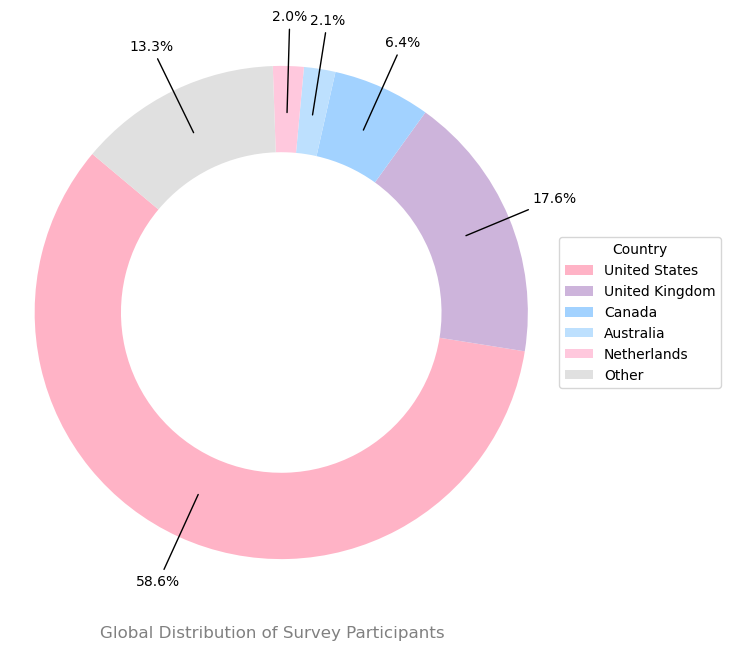

In [203]:
#To παρακατω διαγραμμα τελικα δεν το συμπεριλάβαμε

# Υπολογισμός ποσοστών ανά χώρα
country_percentages = df['Country'].value_counts(normalize=True) * 100

# Top 5 + Other
top5 = country_percentages.head(5)
other = country_percentages.iloc[5:].sum()
final_data = pd.concat([top5, pd.Series({'Other': other})])

# Χρώματα (soft & clean)
colors = ['#ffb3c6', '#cdb4db', '#a2d2ff', '#bde0fe', '#ffc8dd', '#e0e0e0']

# Figure
fig, ax = plt.subplots(figsize=(7, 7))

# Pie / Donut
wedges, _ = ax.pie(
    final_data,
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.35)  # donut effect
)

# Ποσοστά έξω & πλαγίως
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    ax.annotate(
        f"{final_data.iloc[i]:.1f}%",
        xy=(x * 0.8, y * 0.8),
        xytext=(x * 1.2, y * 1.2),
        arrowprops=dict(arrowstyle="-"),
        ha="center",
        va="center",
        fontsize=10
    )

# Legend
ax.legend(
    wedges,
    final_data.index,
    title="Country",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Equal aspect
ax.axis('equal')

# Title ΚΑΤΩ
plt.figtext(
    0.5,
    0.03,
    'Global Distribution of Survey Participants',
    ha='center',
    fontsize=12,
    color='gray'
)

plt.show()

In [204]:
#Διαγραμμα με ποσοστα ερωτηθέντων ανα χώρα

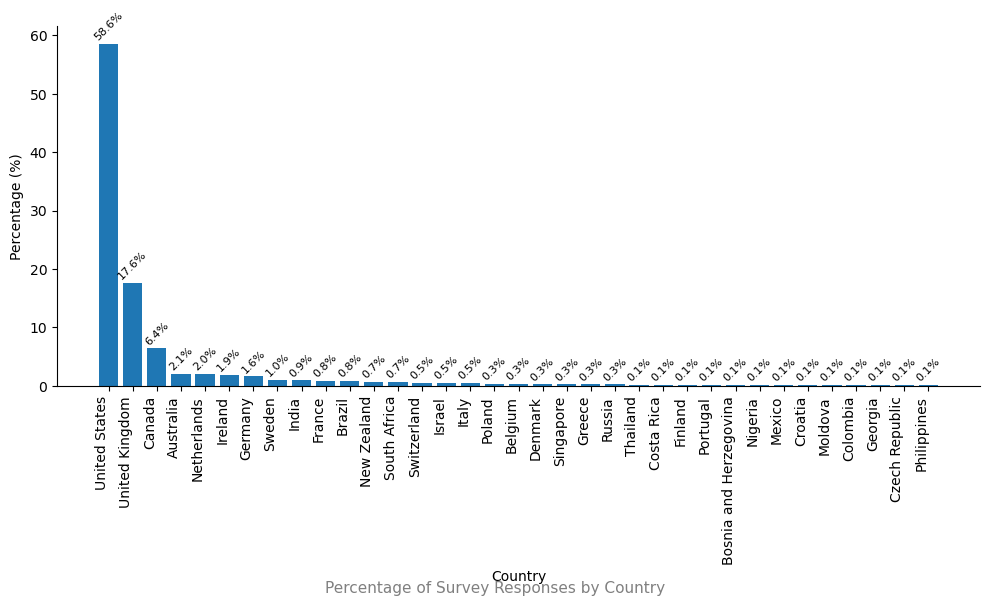

In [205]:


# Υπολογισμός ποσοστών
country_percentages = (
    df['Country']
    .value_counts(normalize=True)
    .sort_values(ascending=False) * 100
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    country_percentages.index,
    country_percentages.values
)

# Άξονες
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Country')

# Περιστροφή labels (απαραίτητο)
plt.xticks(rotation=90, ha='right')

# Ποσοστά πάνω στις μπάρες
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f'{height:.1f}%',
        ha='center',
        rotation=45,
        va='bottom',
        fontsize=8
    )

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Title κάτω
plt.figtext(
    0.5,
    0.01,
    'Percentage of Survey Responses by Country',
    ha='center',
    fontsize=11,
    color='gray'
)

plt.tight_layout()
plt.show()

In [206]:
#ποσοστα male-female ολοκληρου του dataset

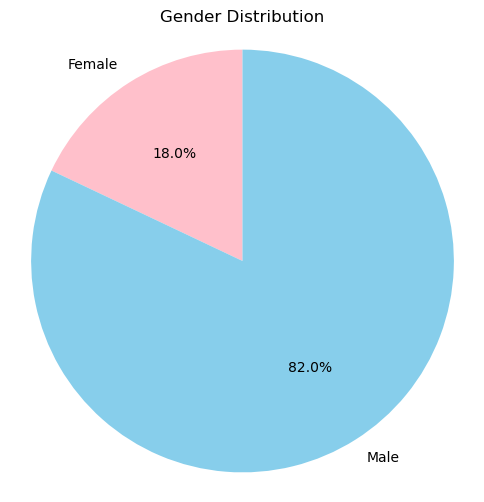

In [207]:
# Υπολογισμός ποσοστών
gender_percentages = df['Gender'].value_counts(normalize=True).loc[['Female', 'Male']] * 100

# Plot
plt.figure(figsize=(6, 6))
plt.pie(
    gender_percentages,
    labels=gender_percentages.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['pink', 'skyblue']
)

plt.title('Gender Distribution')
plt.axis('equal')  # σωστός κύκλος
plt.show()

In [208]:
#Δημιουγία plot για την παρουσιαση του dataset (ανδρες-γυναικες)

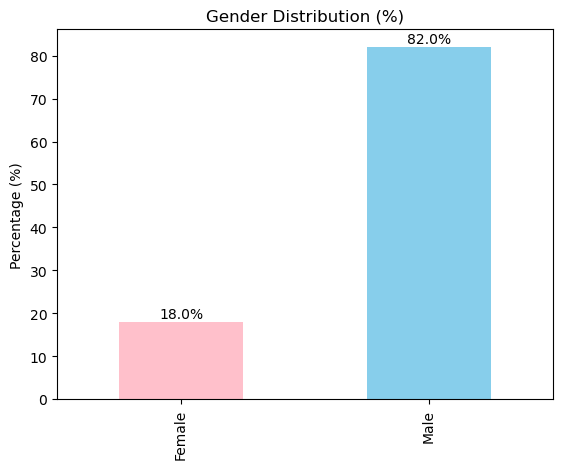

In [209]:


# Υπολογισμός ποσοστών
percentages = df['Gender'].value_counts(normalize=True).loc[['Female', 'Male']] * 100

# Plot
ax = percentages.plot(
    kind='bar',
    color=['pink', 'skyblue']
)

# Labels & title
plt.ylabel('Percentage (%)')
plt.title('Gender Distribution (%)')

# Εμφάνιση ποσοστών πάνω στις μπάρες
for i, value in enumerate(percentages):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.show()

In [210]:
#Διάγραμμα με ποσοστά ανα επάγγελμα 

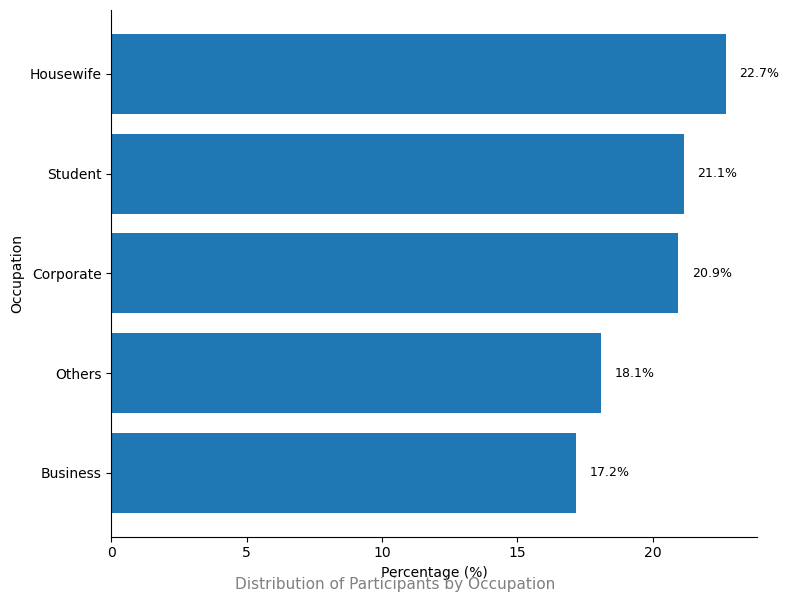

In [211]:

# Υπολογισμός ποσοστών
occupation_percentages = (
    df['Occupation']
    .value_counts(normalize=True)
    .sort_values() * 100
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(
    occupation_percentages.index,
    occupation_percentages.values
)

# Axis labels
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Occupation')

# Ποσοστά πάνω στις μπάρες
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=9
    )

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Title κάτω
plt.figtext(
    0.5,
    0.01,
    'Distribution of Participants by Occupation',
    ha='center',
    fontsize=11,
    color='gray'
)

plt.tight_layout()
plt.show()

In [212]:
#Φιλτραρισμα των female not student

______________________________________________
PLOTS FOR THE GROUP (FEMALE-NOT STUDENT)
______________________________________________

In [213]:
df_females=df[(df['Gender'] == 'Female') & (df['Occupation'] != 'Student')]
df_females.head(3)

,Date,Month,Year,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:00,8,2014,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:00,8,2014,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:00,8,2014,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [214]:
df_females.shape #για να παρουσιασω ποσες παρατηρησεις μελεταω

(40535, 19)

In [215]:
pd.crosstab(df_females['Days_Indoors'], df_females['Changes_Habits']) #αποτυπωση πλήθους  

Changes_Habits,Maybe,No,Yes
Days_Indoors,,,
1-14 days,3146,1936,3025
15-30 days,2178,3025,3025
31-60 days,2904,3025,3146
Go out Every day,2299,2299,2662
More than 2 months,2420,2299,3146


In [216]:
#Διάγραμμα συσχετισης (heatmap) Days Indoors & Changes_Habits

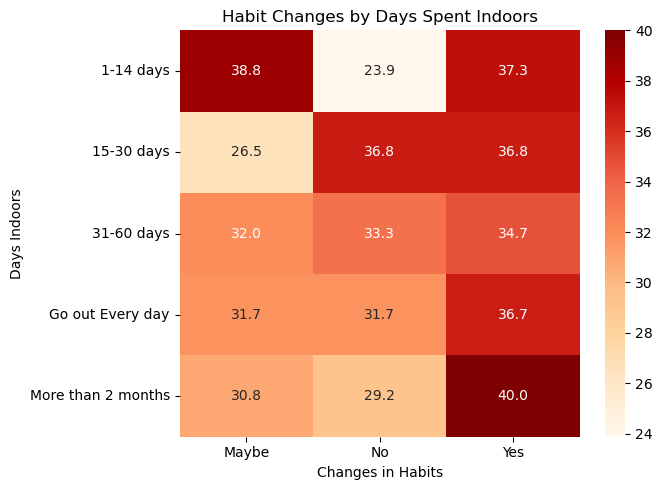

In [297]:

# Crosstab σε ποσοστά
crosstab_pct = (
    pd.crosstab(df_females['Days_Indoors'], df_females['Changes_Habits'], normalize='index') * 100
)

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    crosstab_pct,
    annot=True,
    fmt='.1f',
    cmap='OrRd'   # <<< ζεστά χρώματα
)

plt.xlabel('Changes in Habits')
plt.ylabel('Days Indoors')
plt.title('Habit Changes by Days Spent Indoors')

plt.tight_layout()
plt.show()

In [218]:
#ελεγχος πλήθους ανα συνδυασμό
pd.crosstab(
    df_females['Days_Indoors'],
    df_females['Changes_Habits'],
    normalize='index'
) * 100

Changes_Habits,Maybe,No,Yes
Days_Indoors,,,
1-14 days,38.805970,23.880597,37.313433
15-30 days,26.470588,36.764706,36.764706
31-60 days,32.000000,33.333333,34.666667
Go out Every day,31.666667,31.666667,36.666667
More than 2 months,30.769231,29.230769,40.000000


In [219]:
#εναλλακτικό διάγραμμα (δεν το ανεβασα στην πσρουσίαση)

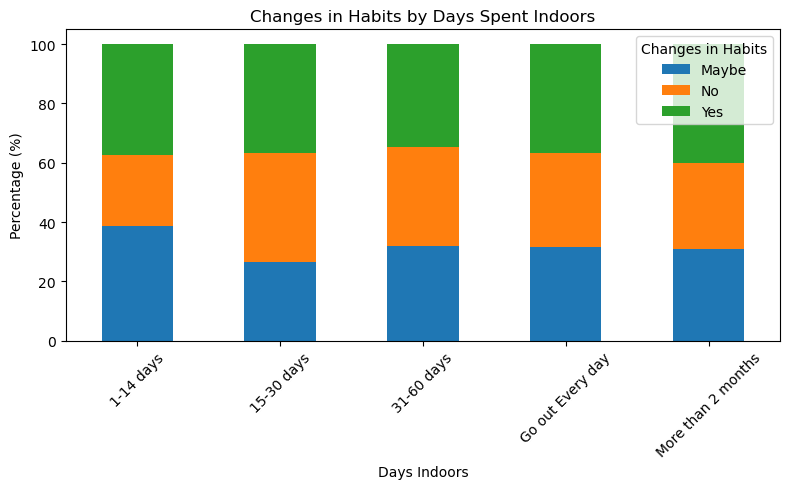

In [220]:

crosstab_pct = (
    pd.crosstab(df_females['Days_Indoors'], df_females['Changes_Habits'], normalize='index') * 100
)

crosstab_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.ylabel('Percentage (%)')
plt.xlabel('Days Indoors')
plt.title('Changes in Habits by Days Spent Indoors')
plt.legend(title='Changes in Habits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [221]:
#Διάγραμμα Occupation - Growing_Stress

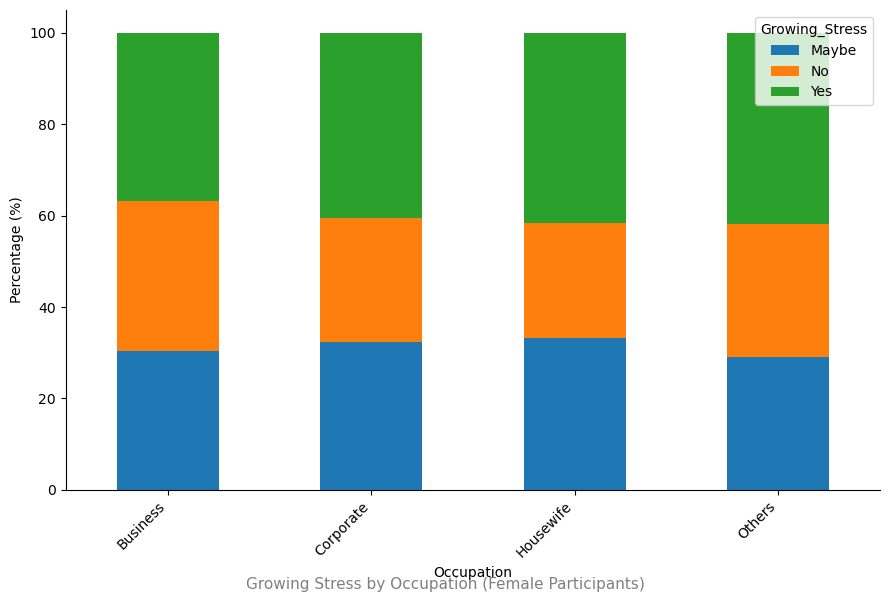

In [222]:
# Crosstab σε ποσοστά
occupation_stress_pct = (
    pd.crosstab(
        df_females['Occupation'],
        df_females['Growing_Stress'],
        normalize='index'
    ) * 100
)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

occupation_stress_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

# Labels
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Occupation')

# Καθαρό look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# X labels
plt.xticks(rotation=45, ha='right')

# Title (κάτω)
plt.figtext(
    0.5,
    0.01,
    'Growing Stress by Occupation (Female Participants)',
    ha='center',
    fontsize=11,
    color='gray'
)

plt.tight_layout()
plt.show()

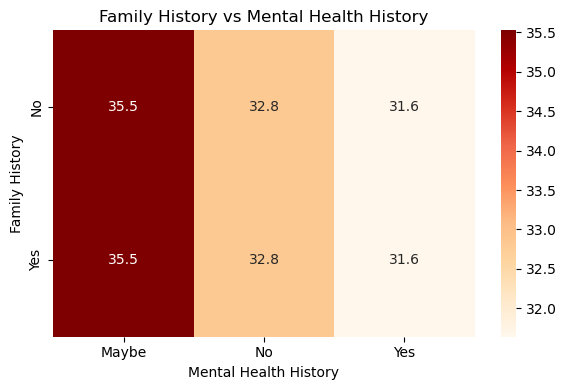

In [295]:
crosstab_pct = (
    pd.crosstab(
        df_females['family_history'],
        df_females['Mental_Health_History'],
        normalize='index'   
    ) * 100
)
plt.figure(figsize=(6, 4))
sns.heatmap(
    crosstab_pct,
    annot=True,
    fmt='.1f',
    cmap='OrRd'
)

plt.xlabel('Mental Health History')
plt.ylabel('Family History')
plt.title('Family History vs Mental Health History')

plt.tight_layout()
plt.show()

In [ ]:
___________________________________________________
CODING AND PLOT FOR THE GROUP OF MALE-NOT STUDENTS
___________________________________________________

In [240]:
df_males = df[(df['Gender'] == 'Male') & (df['Occupation'] != 'Student')]

In [227]:
#we are checking how family history correlates with each persons current mental health

In [228]:
family_history = df['family_history'].value_counts()
family_history

No     176832
Yes    115532
Name: family_history, dtype: int64

In [229]:
mapping = {
    'Yes': 1,
    'No': 0,
    'Maybe': 0.5,
    'Not sure': 0.5
}

In [230]:
cols_to_replace = ['Growing_Stress', 'Changes_Habits', 'Mental_Health_History','Mood_Swings', 'Social_Weakness', 'mental_health_interview', 'care_options']
df_males[cols_to_replace] = df_males[cols_to_replace].replace(mapping)

C:\Users\oly_a\AppData\Local\Temp\ipykernel_7284\2159661050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_males[cols_to_replace] = df_males[cols_to_replace].replace(mapping)


In [231]:
mapping2 = {
    'Yes': 0,
    'No': 1,
    'Maybe': 0.5,
    'Not sure': 0.5
}

In [232]:
cols_to_replace2 = ['Coping_Struggles','Work_Interest']
df_males[cols_to_replace2] = df_males[cols_to_replace2].replace(mapping2)

C:\Users\oly_a\AppData\Local\Temp\ipykernel_7284\2087561343.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_males[cols_to_replace2] = df_males[cols_to_replace2].replace(mapping2)


In [233]:
mapping3 = {
    'High': 1,
    'Medium': 0.5,
    'Low': 0,
}

In [234]:
cols_to_replace3 = ['Mood_Swings']
df_males[cols_to_replace3] = df_males[cols_to_replace3].replace(mapping3)

C:\Users\oly_a\AppData\Local\Temp\ipykernel_7284\1142675139.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_males[cols_to_replace3] = df_males[cols_to_replace3].replace(mapping3)


In [235]:
df['Mood_Swings'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [236]:
df_males.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 190035 entries, 52514 to 292363
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Date                     190035 non-null  datetime64[ns]
 1   Month                    190035 non-null  int64         
 2   Year                     190035 non-null  int64         
 3   Gender                   190035 non-null  object        
 4   Country                  190035 non-null  object        
 5   Occupation               190035 non-null  object        
 6   self_employed            190035 non-null  object        
 7   family_history           190035 non-null  object        
 8   treatment                190035 non-null  object        
 9   Days_Indoors             190035 non-null  object        
 10  Growing_Stress           190035 non-null  float64       
 11  Changes_Habits           190035 non-null  float64       
 12  Mental_Healt

In [237]:
cols_to_sum = [
    'Growing_Stress',
    'Changes_Habits',
    'Mental_Health_History',
    'Mood_Swings',
    'Coping_Struggles',
    'Work_Interest',
    'Social_Weakness',
    'mental_health_interview',
    'care_options'
]

In [238]:
df_males['Total_Score'] = df_males[cols_to_sum].sum(axis=1)

C:\Users\oly_a\AppData\Local\Temp\ipykernel_7284\1457273678.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_males['Total_Score'] = df_males[cols_to_sum].sum(axis=1)


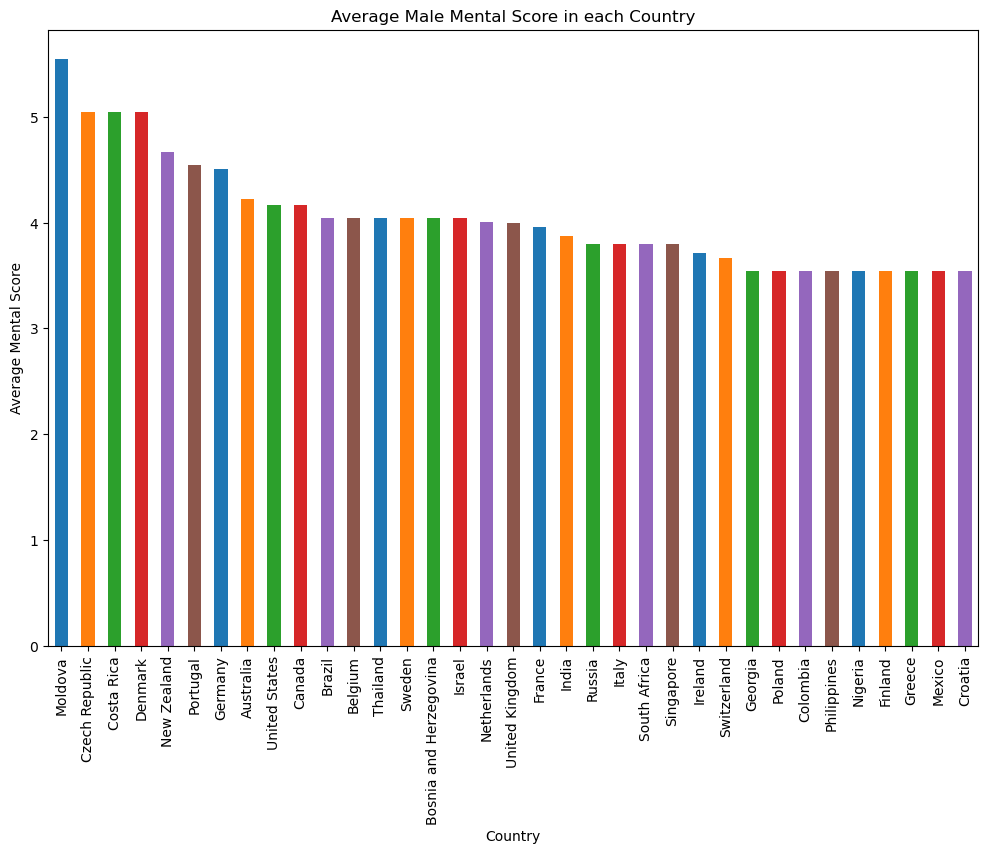

In [239]:
males_score = df_males.groupby('Country')['Total_Score'].mean().sort_values(ascending=False).plot.bar(figsize=(12,8),xlabel=('Country'),color = ['#1f77b4', '#ff7f0e', '#2ca02c', 
          '#d62728', '#9467bd', '#8c564b'],ylabel = ('Average Mental Score'),title=('Average Male Mental Score in each Country'))
None

Our Total Score indicates and sum a lot of different factors such as Growing_Stress, 
Changes_Habits, Mental_Health_History,Mood_Swings, Social_Weakness, mental_health_interview, care_options)
1.)Higher Score means greater impact in overall Mental Health per Male person 
2.)Lower Score means lesser impact in overall Mental Health
3.)Moldova seems to be leading in Mental Health issues 
4.)Croatia,Greece,Mexico etc. countries seem to have the best work-to-life and general mental Illness balance

In [ ]:
______________________________________________
CODING AND PLOTS FOR THE GROUP STUDENTS
______________________________________________

In [255]:
students_df = df.loc[df['Occupation'] == 'Student']

In [256]:
students_df

,Date,Month,Year,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
121,2014-08-27 11:29:00,8,2014,Female,United States,Student,No,No,Yes,Go out Every day,No,Yes,No,Medium,Yes,Maybe,No,No,Not sure
122,2014-08-27 11:31:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,No,Yes,No,Medium,Yes,Maybe,No,No,No
123,2014-08-27 11:32:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,No,Yes,No,Medium,Yes,Maybe,No,No,Yes
124,2014-08-27 11:37:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,No,Yes,No,Medium,Yes,Maybe,No,Maybe,Yes
125,2014-08-27 11:43:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,No,Yes,No,Medium,Yes,Maybe,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291744,2015-07-27 23:25:00,7,2015,Male,United States,Student,Yes,Yes,Yes,More than 2 months,Yes,Maybe,No,High,Yes,Yes,Maybe,Maybe,Not sure
291745,2015-08-17 09:38:00,8,2015,Male,South Africa,Student,No,Yes,Yes,More than 2 months,Yes,Maybe,No,High,Yes,Yes,Maybe,No,Yes
291746,2015-08-25 19:59:00,8,2015,Male,United States,Student,No,Yes,No,More than 2 months,Yes,Maybe,No,High,Yes,Yes,Maybe,No,No
291747,2015-09-26 01:07:00,9,2015,Male,United States,Student,No,Yes,Yes,More than 2 months,Yes,Maybe,No,High,Yes,Yes,Maybe,No,Yes


In [257]:
mapping = {
    'Yes': 1,
    'No': 0,
    'Maybe': 0.5,
    'Not sure': 0.5
}

In [258]:
cols_to_replace = ['Growing_Stress', 'Changes_Habits', 'Mental_Health_History','Mood_Swings', 'Social_Weakness', 'mental_health_interview', 'care_options']

In [259]:
students_df[cols_to_replace] = students_df[cols_to_replace].replace(mapping)

C:\Users\oly_a\AppData\Local\Temp\ipykernel_7284\107158824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  students_df[cols_to_replace] = students_df[cols_to_replace].replace(mapping)


In [260]:
students_df

,Date,Month,Year,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
121,2014-08-27 11:29:00,8,2014,Female,United States,Student,No,No,Yes,Go out Every day,0.0,1.0,0.0,Medium,Yes,Maybe,0.0,0.0,0.5
122,2014-08-27 11:31:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,Medium,Yes,Maybe,0.0,0.0,0.0
123,2014-08-27 11:32:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,Medium,Yes,Maybe,0.0,0.0,1.0
124,2014-08-27 11:37:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,Medium,Yes,Maybe,0.0,0.5,1.0
125,2014-08-27 11:43:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,Medium,Yes,Maybe,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291744,2015-07-27 23:25:00,7,2015,Male,United States,Student,Yes,Yes,Yes,More than 2 months,1.0,0.5,0.0,High,Yes,Yes,0.5,0.5,0.5
291745,2015-08-17 09:38:00,8,2015,Male,South Africa,Student,No,Yes,Yes,More than 2 months,1.0,0.5,0.0,High,Yes,Yes,0.5,0.0,1.0
291746,2015-08-25 19:59:00,8,2015,Male,United States,Student,No,Yes,No,More than 2 months,1.0,0.5,0.0,High,Yes,Yes,0.5,0.0,0.0
291747,2015-09-26 01:07:00,9,2015,Male,United States,Student,No,Yes,Yes,More than 2 months,1.0,0.5,0.0,High,Yes,Yes,0.5,0.0,1.0


In [261]:
mapping1 = {
    'Yes': 0,
    'No': 1,
    'Maybe': 0.5,
    'Not sure': 0.5
}

In [262]:
cols_to_replace1 = ['Coping_Struggles','Work_Interest']

In [263]:
students_df[cols_to_replace1] = students_df[cols_to_replace1].replace(mapping1)

C:\Users\oly_a\AppData\Local\Temp\ipykernel_7284\3020721766.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  students_df[cols_to_replace1] = students_df[cols_to_replace1].replace(mapping1)


In [ ]:
students_df

In [264]:
students_df['Mood_Swings'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [265]:
mapping2 = {
    'High': 1,
    'Low': 0,
    'Medium': 0.5,
}

In [266]:
cols_to_replace2 = ['Mood_Swings']

In [267]:
students_df[cols_to_replace2] = students_df[cols_to_replace2].replace(mapping2)

C:\Users\oly_a\AppData\Local\Temp\ipykernel_7284\1892841719.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  students_df[cols_to_replace2] = students_df[cols_to_replace2].replace(mapping2)


In [268]:
students_df

,Date,Month,Year,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
121,2014-08-27 11:29:00,8,2014,Female,United States,Student,No,No,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.0,0.5
122,2014-08-27 11:31:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.0,0.0
123,2014-08-27 11:32:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.0,1.0
124,2014-08-27 11:37:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.5,1.0
125,2014-08-27 11:43:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291744,2015-07-27 23:25:00,7,2015,Male,United States,Student,Yes,Yes,Yes,More than 2 months,1.0,0.5,0.0,1.0,0,0.0,0.5,0.5,0.5
291745,2015-08-17 09:38:00,8,2015,Male,South Africa,Student,No,Yes,Yes,More than 2 months,1.0,0.5,0.0,1.0,0,0.0,0.5,0.0,1.0
291746,2015-08-25 19:59:00,8,2015,Male,United States,Student,No,Yes,No,More than 2 months,1.0,0.5,0.0,1.0,0,0.0,0.5,0.0,0.0
291747,2015-09-26 01:07:00,9,2015,Male,United States,Student,No,Yes,Yes,More than 2 months,1.0,0.5,0.0,1.0,0,0.0,0.5,0.0,1.0


In [269]:
cols_to_sum = [
    'Growing_Stress',
    'Changes_Habits',
    'Mental_Health_History',
    'Mood_Swings',
    'Coping_Struggles',
    'Work_Interest',
    'Social_Weakness',
    'mental_health_interview',
    'care_options'
]

In [270]:
students_df['Total_Score'] = students_df[cols_to_sum].sum(axis=1)

C:\Users\oly_a\AppData\Local\Temp\ipykernel_7284\1929807626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  students_df['Total_Score'] = students_df[cols_to_sum].sum(axis=1)


In [271]:
students_df

,Date,Month,Year,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Total_Score
121,2014-08-27 11:29:00,8,2014,Female,United States,Student,No,No,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.0,0.5,2.5
122,2014-08-27 11:31:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.0,0.0,2.0
123,2014-08-27 11:32:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.0,1.0,3.0
124,2014-08-27 11:37:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.5,1.0,3.5
125,2014-08-27 11:43:00,8,2014,Female,United States,Student,No,Yes,Yes,Go out Every day,0.0,1.0,0.0,0.5,0,0.5,0.0,0.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291744,2015-07-27 23:25:00,7,2015,Male,United States,Student,Yes,Yes,Yes,More than 2 months,1.0,0.5,0.0,1.0,0,0.0,0.5,0.5,0.5,4.0
291745,2015-08-17 09:38:00,8,2015,Male,South Africa,Student,No,Yes,Yes,More than 2 months,1.0,0.5,0.0,1.0,0,0.0,0.5,0.0,1.0,4.0
291746,2015-08-25 19:59:00,8,2015,Male,United States,Student,No,Yes,No,More than 2 months,1.0,0.5,0.0,1.0,0,0.0,0.5,0.0,0.0,3.0
291747,2015-09-26 01:07:00,9,2015,Male,United States,Student,No,Yes,Yes,More than 2 months,1.0,0.5,0.0,1.0,0,0.0,0.5,0.0,1.0,4.0


In [272]:
mental_illness = students_df.groupby(['Country'])['Total_Score'].mean().sort_values(ascending=False)

In [273]:
mental_illness

Country
Moldova                   5.691358
Costa Rica                5.191358
Czech Republic            5.191358
Denmark                   5.191358
Portugal                  4.691358
Germany                   4.649691
New Zealand               4.508274
Canada                    4.315067
Australia                 4.296814
Sweden                    4.292703
United States             4.268799
Israel                    4.191358
Thailand                  4.191358
Bosnia and Herzegovina    4.191358
Brazil                    4.191358
Poland                    4.136111
United Kingdom            4.130477
France                    4.108025
Netherlands               4.103001
Belgium                   4.086111
South Africa              4.072104
India                     4.020513
Italy                     3.941358
Singapore                 3.941358
Russia                    3.941358
Ireland                   3.882051
Switzerland               3.816358
Mexico                    3.691358
Philippines 

In [274]:
students_df_sorted = students_df.sort_values(by='Country')

In [275]:
students_df_sorted

,Date,Month,Year,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Total_Score
256995,2014-08-27 23:30:00,8,2014,Male,Australia,Student,No,No,No,More than 2 months,0.0,0.5,1.0,0.0,0,0.0,0.5,0.0,0.0,2.0
80490,2014-08-27 23:30:00,8,2014,Male,Australia,Student,No,No,No,Go out Every day,0.0,1.0,1.0,0.5,1,1.0,0.5,0.0,0.0,5.0
207164,2014-08-27 21:54:00,8,2014,Male,Australia,Student,No,No,Yes,31-60 days,0.0,0.5,1.0,1.0,0,0.5,0.0,0.0,0.0,3.0
268350,2015-02-21 04:55:00,2,2015,Male,Australia,Student,No,No,Yes,Go out Every day,1.0,0.0,0.0,1.0,1,1.0,0.0,0.0,1.0,5.0
286329,2014-08-27 13:19:00,8,2014,Male,Australia,Student,Yes,No,No,Go out Every day,0.5,0.5,0.0,1.0,1,0.0,0.0,0.0,0.5,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120835,2014-08-27 12:28:00,8,2014,Male,United States,Student,No,No,Yes,31-60 days,0.0,0.5,0.5,1.0,1,1.0,0.5,0.0,0.0,4.5
120836,2014-08-27 12:29:00,8,2014,Male,United States,Student,No,No,Yes,31-60 days,0.0,0.5,0.5,1.0,1,1.0,0.5,0.0,1.0,5.5
120837,2014-08-27 12:31:00,8,2014,Male,United States,Student,No,No,Yes,31-60 days,0.0,0.5,0.5,1.0,1,1.0,0.5,0.0,1.0,5.5
120842,2014-08-27 12:31:00,8,2014,Male,United States,Student,No,No,Yes,31-60 days,0.0,0.5,0.5,1.0,1,1.0,0.5,0.0,0.0,4.5


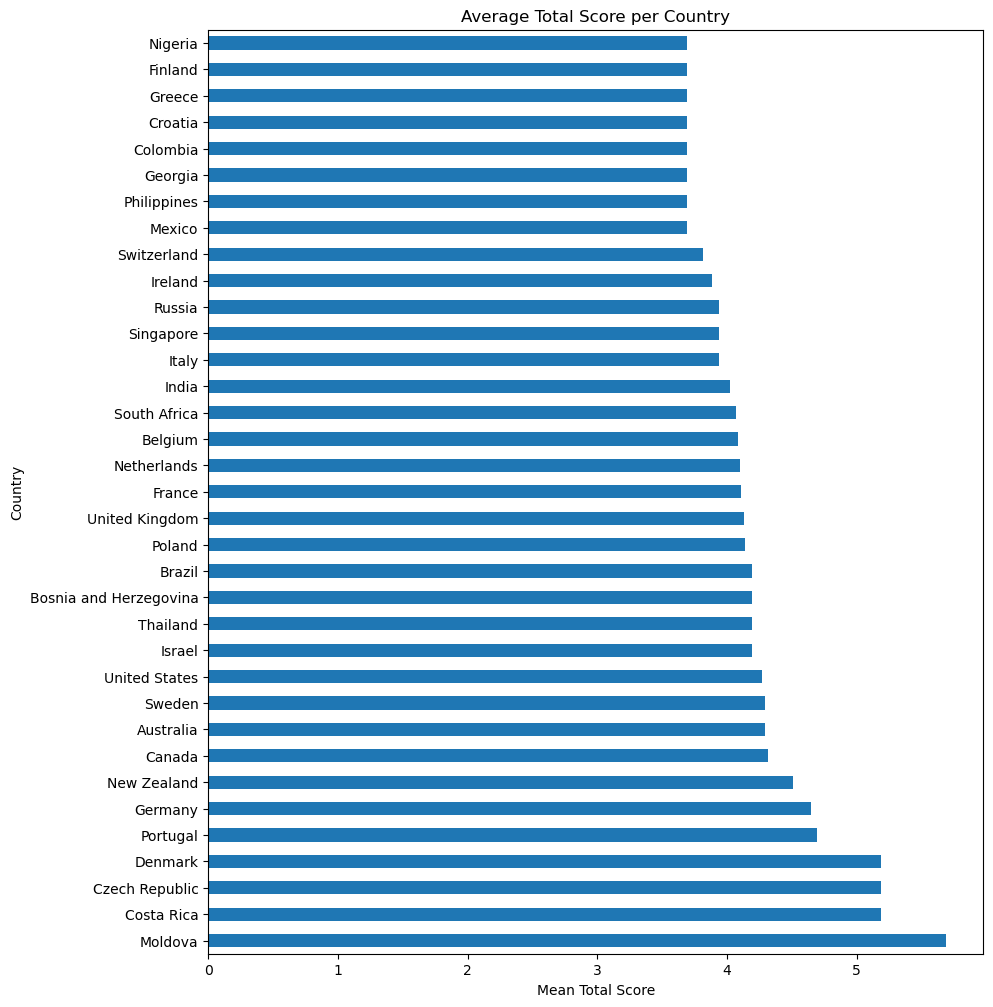

In [276]:
mental_illness.plot(kind='barh', figsize=(10,12))

plt.title('Average Total Score per Country')
plt.xlabel('Mean Total Score')
plt.ylabel('Country')
plt.show()

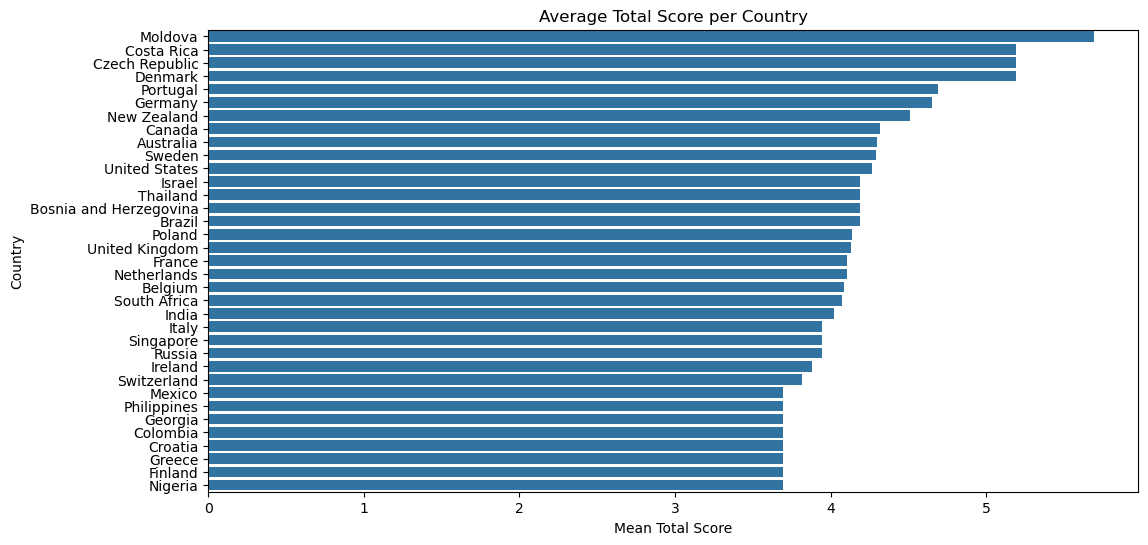

In [277]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x=mental_illness.values, y=mental_illness.index)

plt.title('Average Total Score per Country')
plt.xlabel('Mean Total Score')
plt.ylabel('Country')
plt.show()

In [278]:
grouped = students_df.groupby(['Country', 'Gender'])['Total_Score'].mean()

In [279]:
grouped

Country                 Gender
Australia               Female    4.125000
                        Male      4.373176
Belgium                 Female    4.000000
                        Male      4.191358
Bosnia and Herzegovina  Male      4.191358
Brazil                  Male      4.191358
Canada                  Female    4.333333
                        Male      4.309779
Colombia                Male      3.691358
Costa Rica              Male      5.191358
Croatia                 Male      3.691358
Czech Republic          Male      5.191358
Denmark                 Male      5.191358
Finland                 Male      3.691358
France                  Male      4.108025
Georgia                 Male      3.691358
Germany                 Male      4.649691
Greece                  Male      3.691358
India                   Female    4.000000
                        Male      4.024691
Ireland                 Female    4.000000
                        Male      3.858025
Israel                 

In [282]:
grouped = students_df.groupby(['Country', 'Gender'])['Total_Score'].agg(['mean', 'count'])

In [283]:
grouped = grouped.reset_index()

In [284]:
grouped = grouped.rename(columns={'mean': 'Avg_Total_Score', 'count': 'Count_Per_Gender'})

In [285]:
grouped

,Country,Gender,Avg_Total_Score,Count_Per_Gender
0,Australia,Female,4.125000,396
1,Australia,Male,4.373176,891
2,Belgium,Female,4.000000,99
3,Belgium,Male,4.191358,81
4,Bosnia and Herzegovina,Male,4.191358,81
5,Brazil,Male,4.191358,486
6,Canada,Female,4.333333,891
7,Canada,Male,4.309779,3078
8,Colombia,Male,3.691358,81
9,Costa Rica,Male,5.191358,81


In [ ]:
# -----------------------

In [286]:
students_df_sorted

,Date,Month,Year,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Total_Score
256995,2014-08-27 23:30:00,8,2014,Male,Australia,Student,No,No,No,More than 2 months,0.0,0.5,1.0,0.0,0,0.0,0.5,0.0,0.0,2.0
80490,2014-08-27 23:30:00,8,2014,Male,Australia,Student,No,No,No,Go out Every day,0.0,1.0,1.0,0.5,1,1.0,0.5,0.0,0.0,5.0
207164,2014-08-27 21:54:00,8,2014,Male,Australia,Student,No,No,Yes,31-60 days,0.0,0.5,1.0,1.0,0,0.5,0.0,0.0,0.0,3.0
268350,2015-02-21 04:55:00,2,2015,Male,Australia,Student,No,No,Yes,Go out Every day,1.0,0.0,0.0,1.0,1,1.0,0.0,0.0,1.0,5.0
286329,2014-08-27 13:19:00,8,2014,Male,Australia,Student,Yes,No,No,Go out Every day,0.5,0.5,0.0,1.0,1,0.0,0.0,0.0,0.5,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120835,2014-08-27 12:28:00,8,2014,Male,United States,Student,No,No,Yes,31-60 days,0.0,0.5,0.5,1.0,1,1.0,0.5,0.0,0.0,4.5
120836,2014-08-27 12:29:00,8,2014,Male,United States,Student,No,No,Yes,31-60 days,0.0,0.5,0.5,1.0,1,1.0,0.5,0.0,1.0,5.5
120837,2014-08-27 12:31:00,8,2014,Male,United States,Student,No,No,Yes,31-60 days,0.0,0.5,0.5,1.0,1,1.0,0.5,0.0,1.0,5.5
120842,2014-08-27 12:31:00,8,2014,Male,United States,Student,No,No,Yes,31-60 days,0.0,0.5,0.5,1.0,1,1.0,0.5,0.0,0.0,4.5


In [ ]:
### απο αυτο students_df_sorted να βρω για τις γραμμες με μεγαλύτερο Total Score από το mean, το ποσοστα ανα distinct value της στηλης Days indoor

In [287]:
mean_score = students_df_sorted['Total_Score'].mean()
print(mean_score)

4.232910962229343


In [288]:
above_mean = students_df_sorted[students_df_sorted['Total_Score'] > mean_score]

In [289]:
percentages = above_mean['Days_Indoors'].value_counts(normalize=True) * 100
print(percentages)

Go out Every day      23.641393
1-14 days             20.667101
15-30 days            19.925155
31-60 days            17.894566
More than 2 months    17.871787
Name: Days_Indoors, dtype: float64


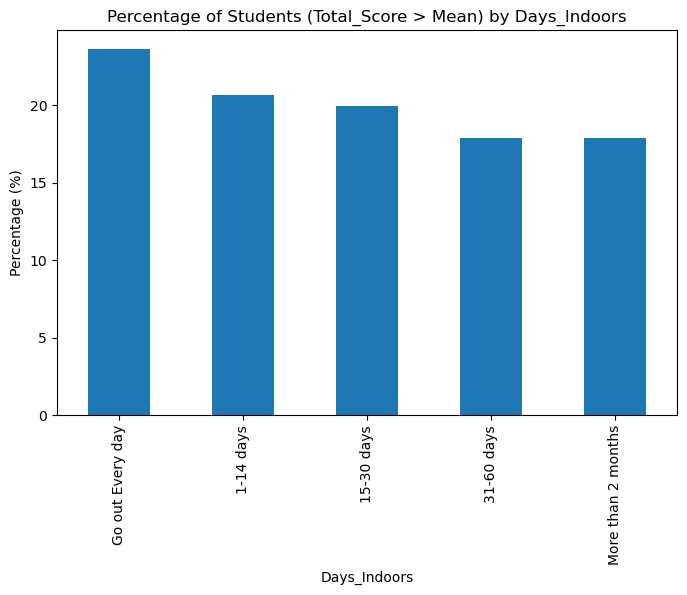

In [290]:
import matplotlib.pyplot as plt

percentages.plot(kind='bar', figsize=(8,5))
plt.title('Percentage of Students (Total_Score > Mean) by Days_Indoors')
plt.ylabel('Percentage (%)')
plt.xlabel('Days_Indoors')
plt.show()

In [291]:
###απο αυτο students_df_sorted να βρω για τις γραμμες με μεγαλύτερο Total Score από το mean, το ποσοστα ανα distinct value της στηλης family_history

In [292]:
percentages = above_mean['family_history'].value_counts(normalize=True) * 100
print(percentages)

No     59.619265
Yes    40.380735
Name: family_history, dtype: float64


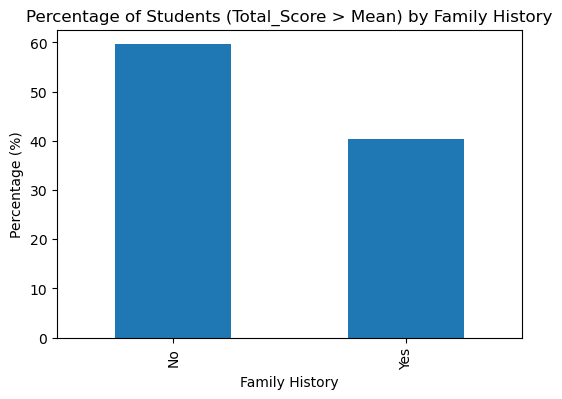

In [293]:
import matplotlib.pyplot as plt

percentages.plot(kind='bar', figsize=(6,4))
plt.title('Percentage of Students (Total_Score > Mean) by Family History')
plt.ylabel('Percentage (%)')
plt.xlabel('Family History')
plt.show()